# *CGH optimization with phase-only slm*
**Author:** Gawoon Ban, Dong-Ha Shin | **Last Updated:** 2025-03-20

Comparing `CGH` optimization techniques, including `Gerchberg-Saxton` (GS), `Stochastic Gradient Descent` (SGD) and `Adaptive Moment Estimation` (ADAM).

In this code, We proceed Tutorial 2.3 with optimizing `phase only SLM`(not complex SLM).

In [1]:
cd ../..

c:\Users\yilin\pado


---

## 🌊 **Step 1: Import Pado**
First, you should import `Pado`. Make sure to install all the dependency

In [2]:
import pado
from pado.math import cm, nm, um
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np

## ⚙️ **Step 2: Default value setting**
Sets the values of the variables used in the code. You can change the values in this part to suit your situation.

In [3]:
R = 800  # number of rows
C = 1280  # number of columns
pitch = 10.8 * um  # physical size of each pixel in [m]
wvl = [660 * nm, 520 * nm, 450 * nm]  # wavelength of the light in [m]
dim = (1, 3, R, C)  # dimension of the light [batch, channel, row, column]
device = 'cuda' if torch.cuda.is_available() else 'cpu'
prop = pado.propagator.Propagator('ASM')

dist = 10 * cm  # distance of the propagation in [m]

##  **🤖 Step 3: Implementation of CGH optimization algorithms**
Create an algorithm for `CGH optimization`. `Mode` variable is used to proceed with optimization in each way of `GS`, `SGD`, and `ADAM`.    
 Performance is evaluated by `psnr`.

We modify the IterativeCGH class to enforce `phase-only` constraints during optimization. After each iteration or gradient update, we set the SLM field's amplitude to 1 and retain only the phase.

In [5]:
class IterativeCGH:
    def __init__(self, mode):
        """Create CGH optimization instance for phase-only SLM
        
        Args:
            mode (str): Algorithm type - one of "GS", "SGD", or "ADAM"
        """
        self.mode = mode

    def optimize(self, light, target, z, n_iter=100, prop_model='ASM'):
        """Optimize light field phase to match target intensity pattern for phase-only SLM
        
        Args:
            light (Light): Input light field
            target (Light): Target intensity pattern  
            z (float): Propagation distance in meters
            n_iter (int): Number of iterations (default: 100)
            prop_model (str): Propagation model (default: 'ASM')
        """
        if self.mode == "GS":
            return self.gerchberg_saxton(light, target, z, n_iter, prop_model)
        elif self.mode == "SGD":
            return self.stochastic_gradient_descent(light, target, z, n_iter, prop_model)
        elif self.mode == "ADAM":
            return self.adaptive_moment_estimation(light, target, z, n_iter, prop_model)

    def gerchberg_saxton(self, init_light, target_light, z, n_iter=100, prop_model='ASM'):
        """Implementation of Gerchberg-Saxton phase retrieval algorithm for phase-only SLM"""
        slm_field = init_light.clone()
        prop = pado.propagator.Propagator(prop_model)

        print("Using Gerchberg-Saxton (GS) algorithm")
        for i in range(n_iter):
            if i % 10 == 0:
                psnr = pado.math.calculate_psnr(prop.forward(slm_field, -z).get_intensity(), target_light.get_intensity())
                print(f"Iteration {i}, PSNR: {psnr:.2f}")

            # Enforce phase-only constraint at the SLM plane
            slm_field.set_amplitude_ones()

            # Propagate to the target plane
            recon_field = prop.forward(slm_field, -z)
            # Replace amplitude with target amplitude, keep phase
            recon_field.set_amplitude(target_light.get_amplitude())
            # Propagate back to the SLM plane
            slm_field = prop.forward(recon_field, z)

        # Final phase-only constraint
        slm_field.set_amplitude_ones()
        print("===========================================================")
        return slm_field

    def stochastic_gradient_descent(self, init_light, target_light, z, n_iter=100, prop_model='ASM', lr=1000000):
        """Implementation of SGD-based phase optimization for phase-only SLM"""
        slm_field = init_light.clone()
        prop = pado.propagator.Propagator(prop_model)
        target_amp = target_light.get_amplitude().detach()

        # Optimize only the phase (we'll extract and apply phase-only constraint)
        phase = torch.angle(slm_field.field).requires_grad_(True)
        optimizer = optim.SGD([phase], lr=lr)
        loss_fn = nn.MSELoss()

        print("Using Stochastic Gradient Descent (SGD) algorithm")
        for i in range(n_iter):
            optimizer.zero_grad()

            # Create phase-only SLM field
            slm_field.field = torch.exp(1j * phase)

            recon_field = prop.forward(slm_field, -z)
            recon_amp = recon_field.get_amplitude()
            loss = loss_fn(recon_amp, target_amp)
            loss.backward()
            optimizer.step()

            # Update phase (already handled by optimizer)
            if i % 10 == 0:
                psnr = pado.math.calculate_psnr(prop.forward(slm_field, -z).get_intensity(), target_light.get_intensity())
                print(f"Iteration {i}, PSNR: {psnr:.2f}")

        # Final phase-only field
        slm_field.set_phase(phase)
        print("===========================================================")
        return slm_field

    def adaptive_moment_estimation(self, init_light, target_light, z, n_iter=100, prop_model='ASM', lr=1e-1):
        """Implementation of ADAM optimization for phase-only SLM"""
        slm_field = init_light.clone()
        prop = pado.propagator.Propagator(prop_model)
        target_amp = target_light.get_amplitude().detach()

        # Optimize only the phase
        phase = torch.angle(slm_field.field).requires_grad_(True)
        optimizer = optim.Adam([phase], lr=lr)
        loss_fn = nn.MSELoss()

        print("Using Adaptive Moment Estimation (ADAM) algorithm")
        for i in range(n_iter):
            optimizer.zero_grad()

            # Create phase-only SLM field
            slm_field.field = torch.exp(1j * phase)

            recon_field = prop.forward(slm_field, -z)
            recon_amp = recon_field.get_amplitude()
            loss = loss_fn(recon_amp, target_amp)
            loss.backward()
            optimizer.step()
            if i % 10 == 0:
                psnr = pado.math.calculate_psnr(prop.forward(slm_field, -z).get_intensity(), target_light.get_intensity())
                print(f"Iteration {i}, PSNR: {psnr:.2f}")

        # Final phase-only field
        slm_field.set_phase(phase)
        print("===========================================================")
        return slm_field

##  **🖼️ Step 4: Build objectplane**
Load an example image for CGH optimization.    
This image becomes the ground truth we want to rebuild.

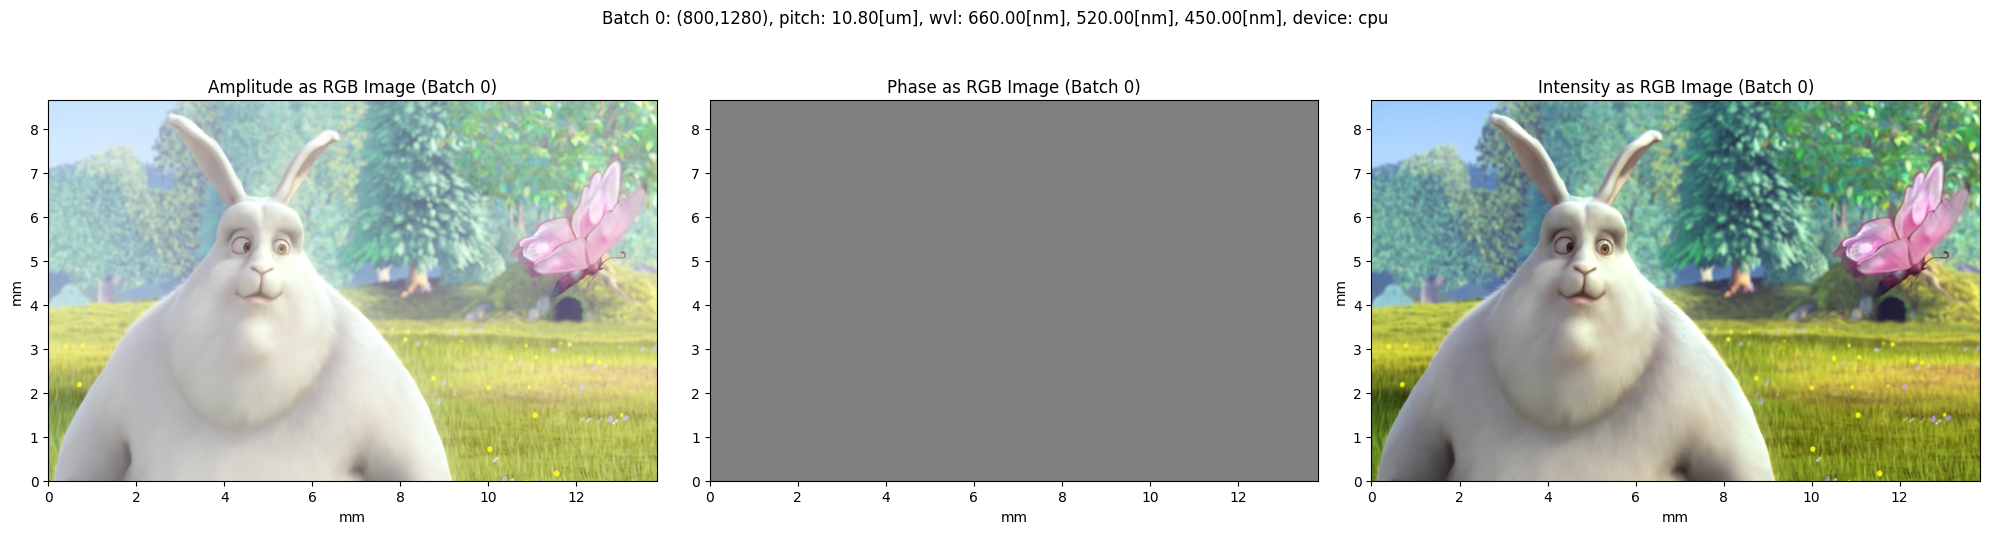

In [6]:
# Load the target image into the object plane
object_plane = pado.light.Light(dim, pitch, wvl, device=device)
object_plane.load_image(r'example/asset/bunny.PNG', random_phase=False)
object_plane.visualize_image()

##  **🤖 Step 5: Activate optimizer and set slm plane**
Set up the SLM plane. Then, optimize the SLM plane using the modified algorithms for a phase-only SLM.

In [8]:
# Create optimizers for each method
GS_optimizer = IterativeCGH(mode="GS")
SGD_optimizer = IterativeCGH(mode="SGD")
ADAM_optimizer = IterativeCGH(mode="ADAM")

# Original SLM plane (propagate from object plane to SLM plane)
SLM_plane = prop.forward(object_plane, dist)

# Make the initial SLM field phase-only
SLM_plane.set_amplitude_ones()

# Optimize the SLM plane with the indoor image using each method
GS_optimized = GS_optimizer.optimize(SLM_plane, object_plane, dist, n_iter=30)
SGD_optimized = SGD_optimizer.optimize(SLM_plane, object_plane, dist, n_iter=200)
ADAM_optimized = ADAM_optimizer.optimize(SLM_plane, object_plane, dist, n_iter=200)

Using Gerchberg-Saxton (GS) algorithm
Iteration 0, PSNR: 6.09
Iteration 10, PSNR: 34.04
Iteration 20, PSNR: 32.62
Using Stochastic Gradient Descent (SGD) algorithm
Iteration 0, PSNR: 6.09
Iteration 10, PSNR: 6.48
Iteration 20, PSNR: 6.72
Iteration 30, PSNR: 7.25
Iteration 40, PSNR: 8.02
Iteration 50, PSNR: 8.84
Iteration 60, PSNR: 9.60
Iteration 70, PSNR: 10.31
Iteration 80, PSNR: 10.99
Iteration 90, PSNR: 11.65
Iteration 100, PSNR: 12.30
Iteration 110, PSNR: 12.93
Iteration 120, PSNR: 13.55
Iteration 130, PSNR: 14.16
Iteration 140, PSNR: 14.75
Iteration 150, PSNR: 15.33
Iteration 160, PSNR: 15.90
Iteration 170, PSNR: 16.44
Iteration 180, PSNR: 16.96
Iteration 190, PSNR: 17.45
Using Adaptive Moment Estimation (ADAM) algorithm
Iteration 0, PSNR: 6.09
Iteration 10, PSNR: 6.51
Iteration 20, PSNR: 7.70
Iteration 30, PSNR: 9.66
Iteration 40, PSNR: 11.70
Iteration 50, PSNR: 13.61
Iteration 60, PSNR: 15.43
Iteration 70, PSNR: 17.08
Iteration 80, PSNR: 18.55
Iteration 90, PSNR: 19.83
Iteration

##  **🎖️ Step 6: Compare optimization result**
Compare the optimization results with each algorithm, which is evaluated through the `psnr` score.

Original Reconstruction PSNR: 6.092361927032471 dB


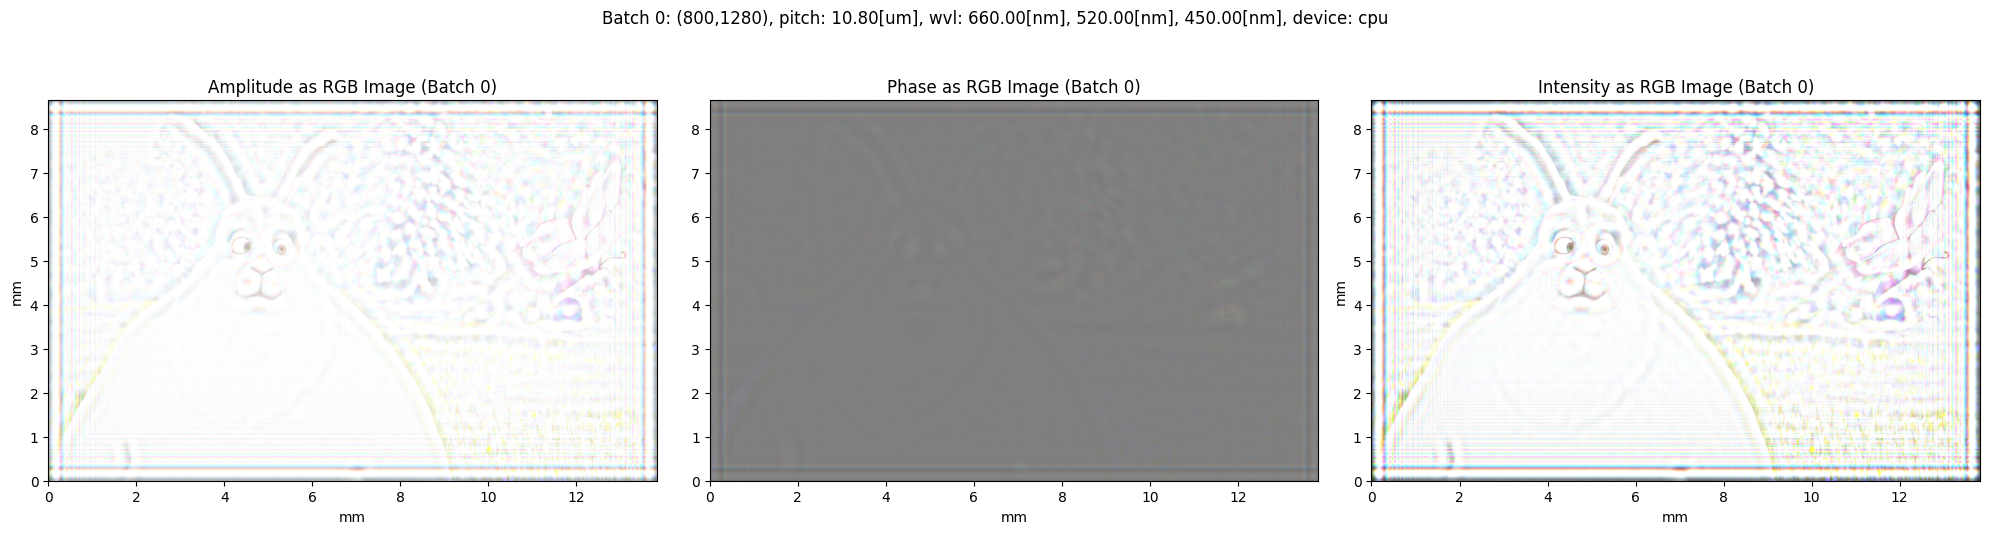

GS Reconstruction PSNR: 6.0545244216918945 dB


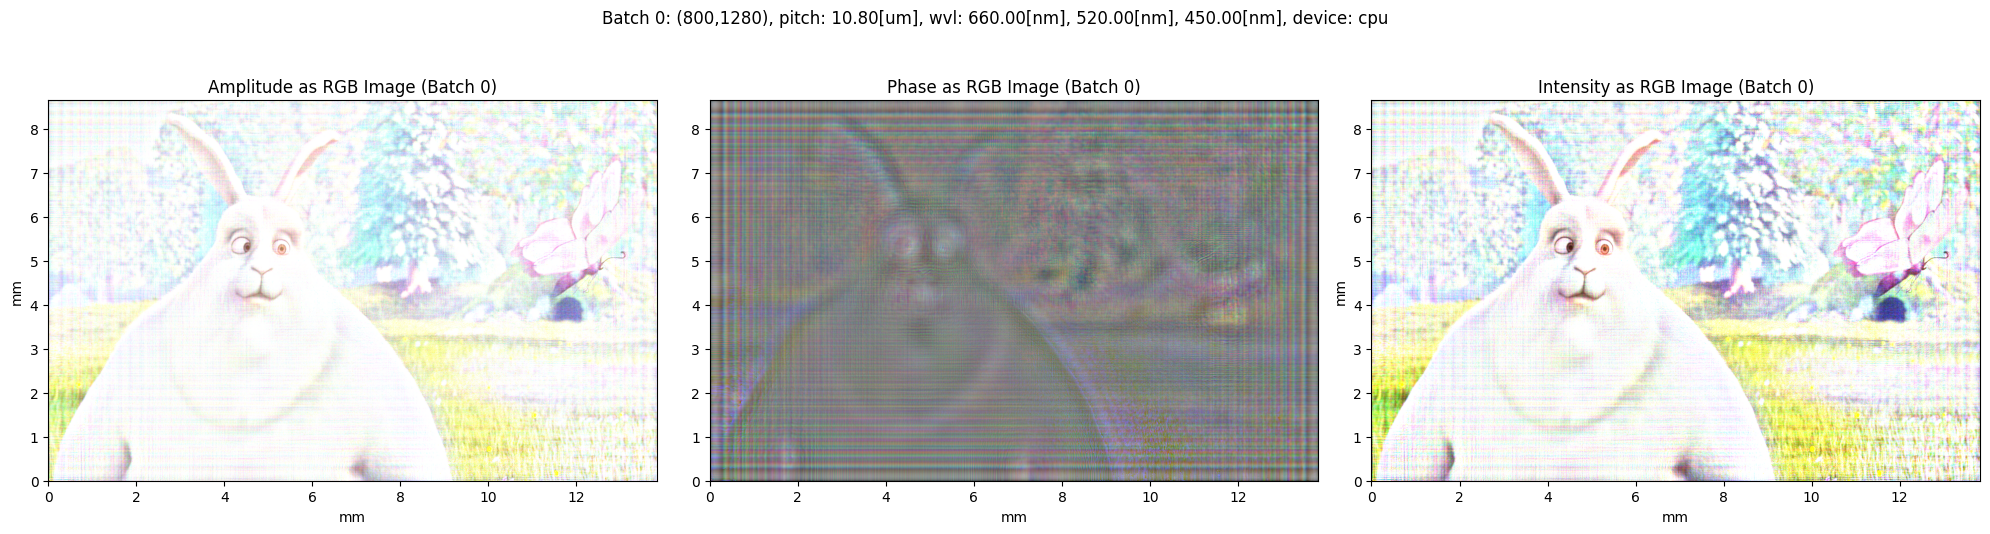

SGD Reconstruction PSNR: 17.921939849853516 dB


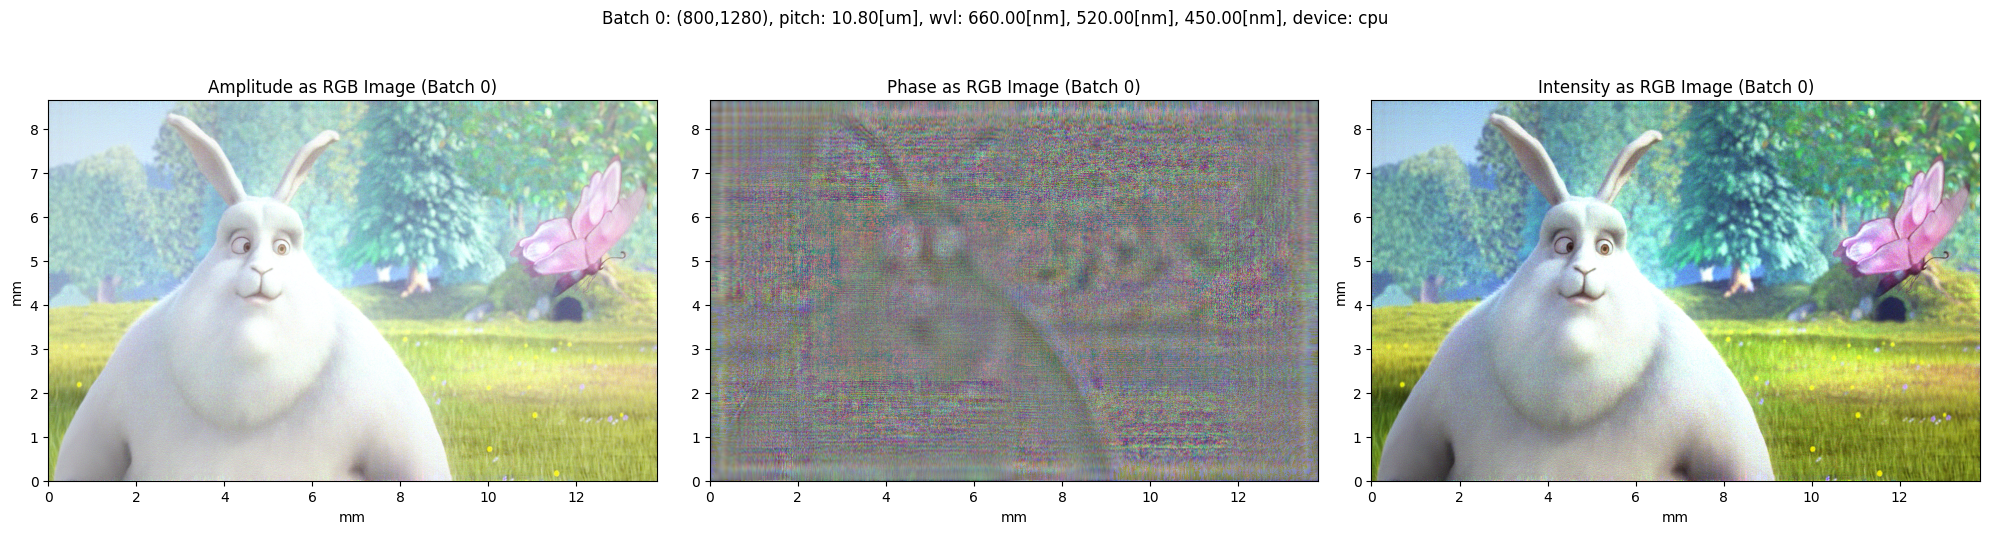

ADAM Reconstruction PSNR: 27.25611686706543 dB


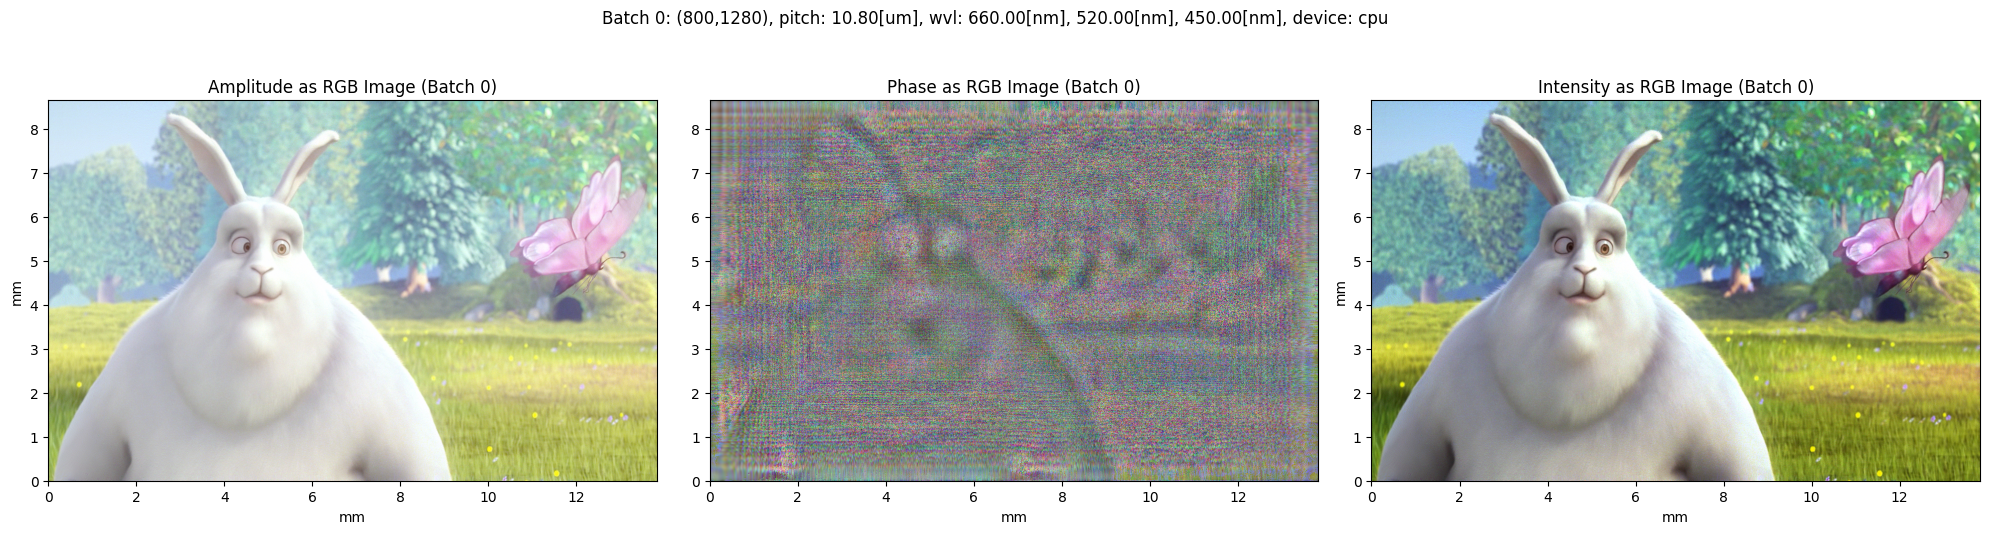

In [9]:
# Reconstruction of the optimized image
original_reconstruction = prop.forward(SLM_plane, -dist)
GS_reconstruction = prop.forward(GS_optimized, -dist)
SGD_reconstruction = prop.forward(SGD_optimized, -dist)
ADAM_reconstruction = prop.forward(ADAM_optimized, -dist)

# PSNR calculation and visualization
print("Original Reconstruction PSNR: {} dB".format(pado.math.calculate_psnr(object_plane.get_intensity(), original_reconstruction.get_intensity())))
original_reconstruction.visualize_image()

print("GS Reconstruction PSNR: {} dB".format(pado.math.calculate_psnr(object_plane.get_intensity(), GS_reconstruction.get_intensity())))
GS_reconstruction.visualize_image()

print("SGD Reconstruction PSNR: {} dB".format(pado.math.calculate_psnr(object_plane.get_intensity(), SGD_reconstruction.get_intensity())))
SGD_reconstruction.visualize_image()

print("ADAM Reconstruction PSNR: {} dB".format(pado.math.calculate_psnr(object_plane.get_intensity(), ADAM_reconstruction.get_intensity())))
ADAM_reconstruction.visualize_image()

## Step 7: Save phase maps and .pt files
Save the optimized SLM phase patterns (4-bit quantized) and reconstructions to `out_phasemaps/`.

In [10]:
import os
from pathlib import Path
from PIL import Image
from datetime import datetime

PHASE_BITS = 4
n_levels = 1 << PHASE_BITS  # 16 for 4-bit

def extract_and_save_phase(optimized_light, label, out_dir, prop, dist, object_plane):
    """Extract phase from an optimized Light, quantize to 4-bit, save .pt and PNGs."""
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)

    # Extract phase from the optimized SLM field -> shape (B, Ch, H, W)
    phase = optimized_light.get_phase()  # radians in [-pi, pi]
    phase = (phase + 2 * torch.pi) % (2 * torch.pi)  # map to [0, 2*pi)
    phase_norm = (phase / (2 * torch.pi)).clamp(0.0, 1.0)

    # Quantize to 4-bit (16 levels)
    phase_norm_q = (phase_norm * (n_levels - 1)).round().clamp(0, n_levels - 1) / (n_levels - 1)

    # Convert from pado (B, Ch, H, W) to output convention (Ch, B, H, W)
    phase_out = phase_norm_q.permute(1, 0, 2, 3).cpu()

    # Save .pt
    pt_path = out_dir / f"{label}_phase.pt"
    torch.save(phase_out, pt_path)
    print(f"Saved {pt_path}  shape={tuple(phase_out.shape)}  {PHASE_BITS}-bit ({n_levels} levels)")

    # Save per-channel PNGs
    ch_names = ["r", "g", "b"] if phase_out.size(0) == 3 else [f"c{i}" for i in range(phase_out.size(0))]
    for c, name in enumerate(ch_names):
        arr8 = (phase_out[c, 0] * (n_levels - 1)).round().clamp(0, n_levels - 1).to(torch.uint8).numpy()
        arr8 = arr8 * (255 // (n_levels - 1))
        Image.fromarray(arr8).save(out_dir / f"{label}_phase_{name}.png")
    print(f"Saved {PHASE_BITS}-bit phase PNGs for {label}")

    # Reconstruct using quantized phase and save reconstruction PNGs
    phase_rad_q = phase_norm_q * (2 * torch.pi)
    recon_light = optimized_light.clone()
    recon_light.set_amplitude_ones()
    recon_light.set_phase(phase_rad_q)
    recon = prop.forward(recon_light, -dist)
    recon_intensity = recon.get_intensity().detach().cpu()  # (B, Ch, H, W)
    for c, name in enumerate(ch_names):
        img = recon_intensity[0, c]
        mx = img.max().item()
        if mx > 0:
            img = img / mx
        arr8 = (img * 255.0).round().clamp(0, 255).to(torch.uint8).numpy()
        Image.fromarray(arr8).save(out_dir / f"{label}_reconstruction_{name}.png")
    print(f"Saved reconstruction PNGs for {label}")

    # Save ground truth
    gt_intensity = object_plane.get_intensity().detach().cpu()
    for c, name in enumerate(ch_names):
        img = gt_intensity[0, c]
        mx = img.max().item()
        if mx > 0:
            img = img / mx
        arr8 = (img * 255.0).round().clamp(0, 255).to(torch.uint8).numpy()
        Image.fromarray(arr8).save(out_dir / f"ground_truth_{name}.png")


out_root = Path("out_phasemaps") / f"cgh_2.5_{datetime.now().strftime('%Y%m%d_%H%M%S')}"

extract_and_save_phase(GS_optimized, "GS", out_root, prop, dist, object_plane)
extract_and_save_phase(SGD_optimized, "SGD", out_root, prop, dist, object_plane)
extract_and_save_phase(ADAM_optimized, "ADAM", out_root, prop, dist, object_plane)

print(f"\nAll outputs saved to: {out_root}")


Saved out_phasemaps\cgh_2.5_20260319_144225\GS_phase.pt  shape=(3, 1, 800, 1280)  4-bit (16 levels)
Saved 4-bit phase PNGs for GS
Saved reconstruction PNGs for GS
Saved out_phasemaps\cgh_2.5_20260319_144225\SGD_phase.pt  shape=(3, 1, 800, 1280)  4-bit (16 levels)
Saved 4-bit phase PNGs for SGD
Saved reconstruction PNGs for SGD
Saved out_phasemaps\cgh_2.5_20260319_144225\ADAM_phase.pt  shape=(3, 1, 800, 1280)  4-bit (16 levels)
Saved 4-bit phase PNGs for ADAM
Saved reconstruction PNGs for ADAM

All outputs saved to: out_phasemaps\cgh_2.5_20260319_144225
